In [8]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path(
    "../data/processed/sparkov_features.parquet"
)

df = pd.read_parquet(DATA_PATH)

print("Shape:", df.shape)
print("Unique transactions:", df["trans_num"].nunique())
print(
    "Duplicate transactions:",
    df["trans_num"].duplicated().sum()
)

print("\nTime range:")
print(df["transaction_time"].min())
print(df["transaction_time"].max())

print("\nTarget distribution:")
print(df["is_fraud"].value_counts())

Shape: (1296675, 25)
Unique transactions: 1296675
Duplicate transactions: 0

Time range:
2019-01-01 00:00:18
2020-06-21 12:13:37

Target distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64


In [9]:
# Make sure data is in chronological order
df = df.sort_values("transaction_time").reset_index(drop=True)

# Define temporal cutoffs
train_end = pd.Timestamp("2020-03-31")
validation_end = pd.Timestamp("2020-05-15")

# Training data
train_df = df[
    df["transaction_time"] < train_end
].copy()

# Validation data
validation_df = df[
    (df["transaction_time"] >= train_end) &
    (df["transaction_time"] < validation_end)
].copy()

# Test data
test_df = df[
    df["transaction_time"] >= validation_end
].copy()

print("TRAIN")
print(train_df["transaction_time"].min(), "→", train_df["transaction_time"].max())
print("Rows:", len(train_df))

print("\nVALIDATION")
print(validation_df["transaction_time"].min(), "→", validation_df["transaction_time"].max())
print("Rows:", len(validation_df))

print("\nTEST")
print(test_df["transaction_time"].min(), "→", test_df["transaction_time"].max())
print("Rows:", len(test_df))

TRAIN
2019-01-01 00:00:18 → 2020-03-30 23:59:46
Rows: 1094645

VALIDATION
2020-03-31 00:01:30 → 2020-05-14 23:59:58
Rows: 101583

TEST
2020-05-15 00:00:11 → 2020-06-21 12:13:37
Rows: 100447


In [10]:
def fraud_summary(name, data):
    fraud_count = data["is_fraud"].sum()
    total = len(data)

    print(
        f"{name}: "
        f"transactions={total:,}, "
        f"fraud={fraud_count:,}, "
        f"fraud_rate={fraud_count / total * 100:.4f}%"
    )

fraud_summary("TRAIN", train_df)
fraud_summary("VALIDATION", validation_df)
fraud_summary("TEST", test_df)

TRAIN: transactions=1,094,645, fraud=6,310, fraud_rate=0.5764%
VALIDATION: transactions=101,583, fraud=615, fraud_rate=0.6054%
TEST: transactions=100,447, fraud=581, fraud_rate=0.5784%


In [5]:
duplicates = (
    df[df["trans_num"].duplicated(keep=False)]
    .sort_values("trans_num")
)

print("Duplicated transaction IDs:")
display(
    duplicates[
        [
            "trans_num",
            "cc_num",
            "transaction_time",
            "amt",
            "transactions_prev_5min",
            "transactions_prev_1h",
            "transactions_prev_24h"
        ]
    ].head(100)
)

Duplicated transaction IDs:


,trans_num,cc_num,transaction_time,amt,transactions_prev_5min,transactions_prev_1h,transactions_prev_24h
392330,008f89cdba4643cfa89529e602d2a9a8,375082648741747,2019-06-28 21:25:50,2.66,0.0,0.0,8.0
392331,008f89cdba4643cfa89529e602d2a9a8,375082648741747,2019-06-28 21:25:50,2.66,0.0,0.0,8.0
893461,059c4159d4a26fe01bbf6f07749a903b,4736845434667908128,2019-12-25 00:01:08,117.50,0.0,0.0,8.0
893462,059c4159d4a26fe01bbf6f07749a903b,4736845434667908128,2019-12-25 00:01:08,117.50,0.0,0.0,8.0
123028,165f8c7e631d3513459979bfd13a95df,3553629419254918,2019-03-10 02:31:27,90.73,0.0,0.0,4.0
...,...,...,...,...,...,...,...
392333,f211adb01a1a37d910e95f4cd38768c7,375082648741747,2019-06-28 21:25:50,5.68,0.0,0.0,8.0
711616,f9efd36d6f5c3ec2b004feb97baa7c25,3560318482131952,2019-10-31 01:16:14,26.88,0.0,0.0,4.0
711619,f9efd36d6f5c3ec2b004feb97baa7c25,3560318482131952,2019-10-31 01:16:14,26.88,0.0,0.0,4.0
841769,fb277314380561f3fdca64ac19d80c8a,676173792455,2019-12-14 01:11:03,49.25,0.0,0.0,2.0


In [11]:
MODEL_FEATURES = [
    "amt",
    "log_amount",
    "hour",
    "day_of_week",
    "month",
    "day_of_month",
    "is_weekend",
    "customer_prev_count",
    "customer_prev_avg_amount",
    "customer_prev_median_amount",
    "customer_prev_std_amount",
    "amount_deviation_ratio",
    "seconds_since_prev_transaction",
    "transactions_prev_5min",
    "transactions_prev_1h",
    "transactions_prev_24h",
    "merchant_seen_before",
    "is_new_merchant",
    "category_seen_before",
    "is_new_category",
    "customer_merchant_distance_km"
]

TARGET = "is_fraud"

In [12]:
X_train = train_df[MODEL_FEATURES].copy()
y_train = train_df[TARGET].copy()

X_val = validation_df[MODEL_FEATURES].copy()
y_val = validation_df[TARGET].copy()

X_test = test_df[MODEL_FEATURES].copy()
y_test = test_df[TARGET].copy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (1094645, 21)
X_val: (101583, 21)
X_test: (100447, 21)


In [13]:
def fraud_summary(name, data):
    fraud_count = data["is_fraud"].sum()
    total = len(data)

    print(
        f"{name}: "
        f"transactions={total:,}, "
        f"fraud={fraud_count:,}, "
        f"fraud_rate={fraud_count / total * 100:.4f}%"
    )

fraud_summary("TRAIN", train_df)
fraud_summary("VALIDATION", validation_df)
fraud_summary("TEST", test_df)

TRAIN: transactions=1,094,645, fraud=6,310, fraud_rate=0.5764%
VALIDATION: transactions=101,583, fraud=615, fraud_rate=0.6054%
TEST: transactions=100,447, fraud=581, fraud_rate=0.5784%


In [14]:
missing_summary = pd.DataFrame({
    "missing_count": X_train.isna().sum(),
    "missing_pct": X_train.isna().mean() * 100
})

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_count", ascending=False)
)

missing_summary


,missing_count,missing_pct
transactions_prev_5min,1077151,98.401856
transactions_prev_1h,913938,83.491726
transactions_prev_24h,92779,8.475716
customer_prev_std_amount,1936,0.176861
amount_deviation_ratio,968,0.088430
customer_prev_median_amount,968,0.088430
customer_prev_avg_amount,968,0.088430
seconds_since_prev_transaction,968,0.088430


In [15]:
velocity_cols = [
    "transactions_prev_5min",
    "transactions_prev_1h",
    "transactions_prev_24h"
]

X_train[velocity_cols] = X_train[velocity_cols].fillna(0)
X_val[velocity_cols] = X_val[velocity_cols].fillna(0)
X_test[velocity_cols] = X_test[velocity_cols].fillna(0)

In [16]:
print(X_train[velocity_cols].isna().sum())

transactions_prev_5min    0
transactions_prev_1h      0
transactions_prev_24h     0
dtype: int64


In [17]:
remaining_missing = pd.DataFrame({
    "train_missing": X_train.isna().sum(),
    "validation_missing": X_val.isna().sum(),
    "test_missing": X_test.isna().sum()
})

remaining_missing = remaining_missing[
    remaining_missing.sum(axis=1) > 0
]

remaining_missing

,train_missing,validation_missing,test_missing
customer_prev_avg_amount,968,12,3
customer_prev_median_amount,968,12,3
customer_prev_std_amount,1936,24,6
amount_deviation_ratio,968,12,3
seconds_since_prev_transaction,968,12,3


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

In [19]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['amt','log_amount','hour',...,'category_seen_before','is_new_category', 'customer_merchant_distance_km']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of m

In [20]:
print("Logistic Regression training complete.")

Logistic Regression training complete.


In [21]:
val_prob = logistic_pipeline.predict_proba(X_val)[:, 1]

print("Validation probabilities generated.")
print("Minimum:", val_prob.min())
print("Maximum:", val_prob.max())

Validation probabilities generated.
Minimum: 0.01241569141934177
Maximum: 1.0


In [22]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

val_pred = (val_prob >= 0.5).astype(int)

print("Precision:", precision_score(y_val, val_pred, zero_division=0))
print("Recall:", recall_score(y_val, val_pred, zero_division=0))
print("F1:", f1_score(y_val, val_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_val, val_prob))
print("PR-AUC:", average_precision_score(y_val, val_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_pred))

Precision: 0.16539992761491132
Recall: 0.7430894308943089
F1: 0.27057430432208407
ROC-AUC: 0.935103595568877
PR-AUC: 0.24905381003196445

Confusion Matrix:
[[98662  2306]
 [  158   457]]


In [23]:
val_pred = (val_prob >= 0.5)

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.01, 1.00, 0.01):

    pred = (val_prob >= threshold).astype(int)

    precision = precision_score(
        y_val,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(
    "f1",
    ascending=False
).head(15)

,threshold,precision,recall,f1
97,0.98,0.394459,0.486179,0.435543
96,0.97,0.379227,0.510569,0.435204
95,0.96,0.365938,0.517073,0.428571
94,0.95,0.357143,0.528455,0.426230
98,0.99,0.407186,0.442276,0.424006
93,0.94,0.347134,0.531707,0.420039
92,0.93,0.336704,0.541463,0.415212
91,0.92,0.329089,0.546341,0.410758
90,0.91,0.320076,0.549593,0.404548
89,0.90,0.312213,0.552846,0.399061


In [25]:
threshold_df[
    threshold_df["recall"] >= 0.70
].sort_values(
    "precision",
    ascending=False
).head(15)

,threshold,precision,recall,f1
60,0.61,0.206023,0.700813,0.318434
59,0.60,0.203947,0.705691,0.316442
58,0.59,0.200644,0.708943,0.312769
57,0.58,0.198015,0.713821,0.310028
56,0.57,0.195154,0.720325,0.307106
55,0.56,0.192341,0.726829,0.304185
54,0.55,0.187656,0.731707,0.298706
53,0.54,0.184232,0.733333,0.294483
52,0.53,0.179395,0.733333,0.288271
51,0.52,0.174720,0.734959,0.282324


In [26]:
threshold_df[
    threshold_df["recall"] >= 0.80
].sort_values(
    "precision",
    ascending=False
).head(15)

,threshold,precision,recall,f1
38,0.39,0.116111,0.809756,0.203100
37,0.38,0.111210,0.813008,0.195656
36,0.37,0.106653,0.821138,0.188785
35,0.36,0.101135,0.826016,0.180206
34,0.35,0.095901,0.829268,0.171920
33,0.34,0.090732,0.834146,0.163662
32,0.33,0.085472,0.834146,0.155055
31,0.32,0.081230,0.837398,0.148095
30,0.31,0.076039,0.839024,0.139441
29,0.30,0.071291,0.842276,0.131455


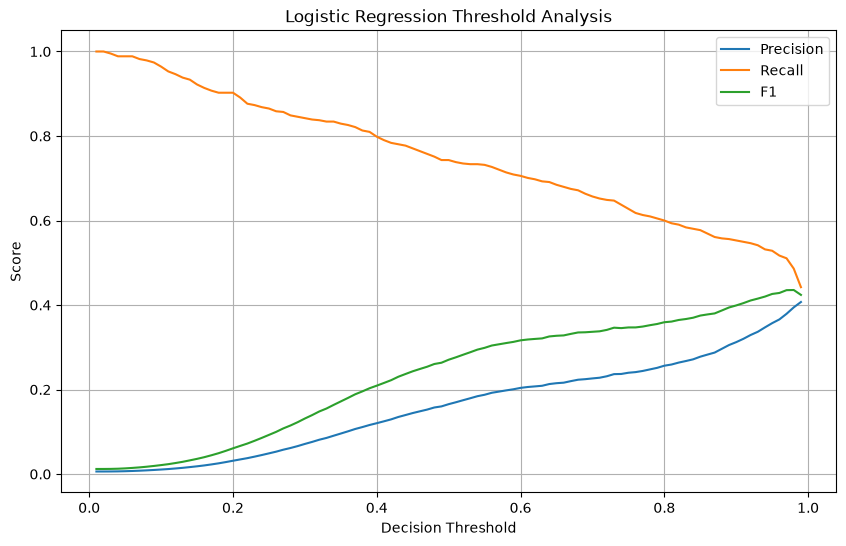

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Logistic Regression Threshold Analysis")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
threshold_df[
    threshold_df["recall"] >= 0.70
].sort_values(
    "precision",
    ascending=False
).head(15)

,threshold,precision,recall,f1
60,0.61,0.206023,0.700813,0.318434
59,0.60,0.203947,0.705691,0.316442
58,0.59,0.200644,0.708943,0.312769
57,0.58,0.198015,0.713821,0.310028
56,0.57,0.195154,0.720325,0.307106
55,0.56,0.192341,0.726829,0.304185
54,0.55,0.187656,0.731707,0.298706
53,0.54,0.184232,0.733333,0.294483
52,0.53,0.179395,0.733333,0.288271
51,0.52,0.174720,0.734959,0.282324


In [29]:
threshold_df[
    threshold_df["recall"] >= 0.80
].sort_values(
    "precision",
    ascending=False
).head(15)

,threshold,precision,recall,f1
38,0.39,0.116111,0.809756,0.203100
37,0.38,0.111210,0.813008,0.195656
36,0.37,0.106653,0.821138,0.188785
35,0.36,0.101135,0.826016,0.180206
34,0.35,0.095901,0.829268,0.171920
33,0.34,0.090732,0.834146,0.163662
32,0.33,0.085472,0.834146,0.155055
31,0.32,0.081230,0.837398,0.148095
30,0.31,0.076039,0.839024,0.139441
29,0.30,0.071291,0.842276,0.131455


## Random Forest Baseline

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

In [31]:
rf_pipeline.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


In [32]:
rf_val_prob = rf_pipeline.predict_proba(X_val)[:, 1]

print("RF ROC-AUC:",
      roc_auc_score(y_val, rf_val_prob))

print("RF PR-AUC:",
      average_precision_score(y_val, rf_val_prob))

RF ROC-AUC: 0.9900226619332986
RF PR-AUC: 0.8107091940807669
